# Representations & Features

Representations are the core of machine learning.
They are the way with which we can go from input data to output prediction, and often represent something about the underlying data points.
Knowing how to craft features is important to describe how you would interpret the data, create better models, make well-informed hypotheses, and so on.

In this notebook, we will learn more about featurization, representations, and how to better engineer these features.

In [1]:
try:
    import google.colab
    IN_COLAB = True
    !git clone https://github.com/dskoda/ml4mat-26s-public.git
    !cd ml4mat-26s-public && pip install . && cd ..
    ROOT = "https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/lectures/03-Features"
    STYLE = "colab"
except:
    IN_COLAB = False
    ROOT = "."
    STYLE = "jupyter"

Cloning into 'ml4mat-26s-public'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 96 (delta 36), reused 84 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (96/96), 6.82 MiB | 10.54 MiB/s, done.
Resolving deltas: 100% (36/36), done.
Processing /content/ml4mat-26s-public
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 638.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.4/777.4 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8

In [2]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy import stats

# RDKit utilities to deal with molecules
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit import DataStructs as DS

def draw_molecules_row(mols, nums=None):
    if nums is not None:
        annotations = [f"{num:.2f}" for num in nums]
    else:
        annotations = None

    img = Draw.MolsToGridImage(mols, molsPerRow=1, subImgSize=(500, 200), legends=annotations)
    return img

import ml4mat_ucla as m4m

plt.style.use(STYLE)
m4m.utils.set_dpi(200)

df = pd.read_csv(f"{ROOT}/data/solubility.csv")

## Initial insights

What are the columns that we have available for the molecules?

In [3]:
df.columns

Index(['ID', 'Name', 'InChI', 'InChIKey', 'SMILES', 'Solubility', 'SD',
       'Ocurrences', 'Group', 'MolWt', 'MolLogP', 'MolMR', 'HeavyAtomCount',
       'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds',
       'NumValenceElectrons', 'NumAromaticRings', 'NumSaturatedRings',
       'NumAliphaticRings', 'RingCount', 'TPSA', 'LabuteASA', 'BalabanJ',
       'BertzCT'],
      dtype='object')

For instance, analyzing the number of rings is a good starting point:

In [4]:
np.sort(df["NumAromaticRings"].unique())

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       14., 16., 35.])

Now we can try to gain insights from the dataset.
For instance, what do we learn as we change the number of aromatic rings?

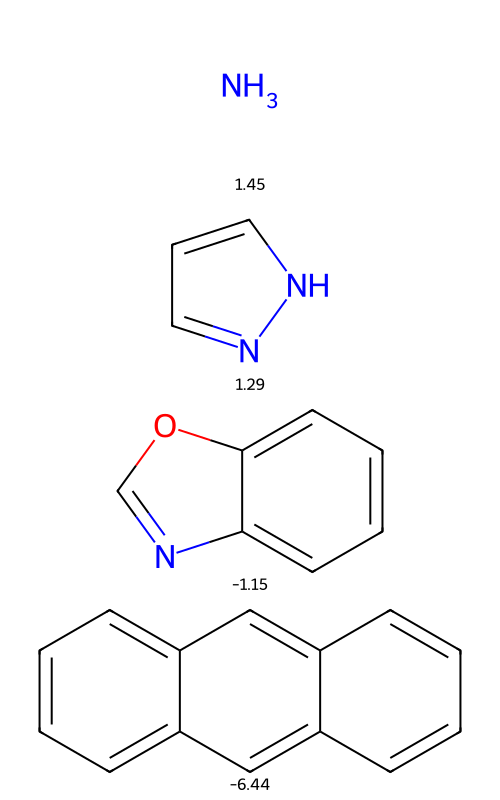

In [5]:
mols = []
sols = []
for n_rings in [0, 1, 2, 3]:
    grp = df.loc[df["NumAromaticRings"] == n_rings].sort_values("MolWt")
    row = grp.iloc[3]
    _mol = Chem.MolFromSmiles(row["SMILES"])
    sols.append(row["Solubility"])
    mols.append(_mol)

draw_molecules_row(mols, sols)

What about keeping the number of rings constant, but seeing molecules that have different solubilities?

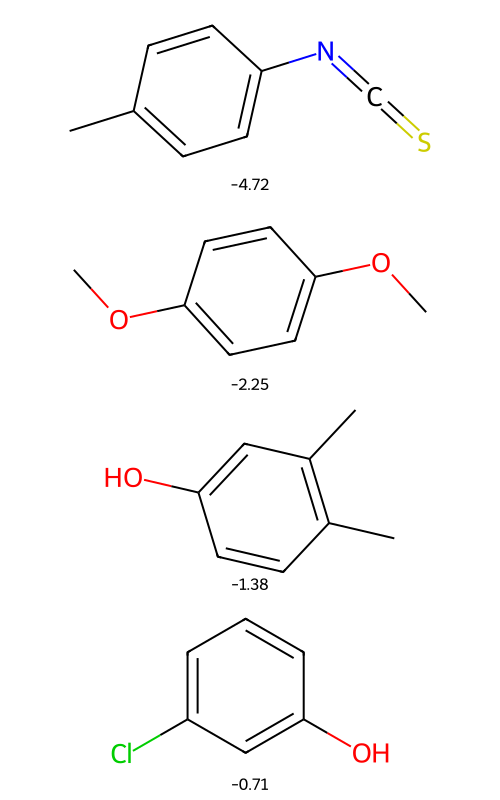

In [6]:
grp = df.loc[(df["NumAromaticRings"] == 1) & (df["MolWt"] < 150)].sort_values("Solubility")
grp = grp.iloc[::100][:4]
mols = [Chem.MolFromSmiles(smi) for smi in grp["SMILES"].values]
sols = grp["Solubility"].values

draw_molecules_row(mols, sols)

## Data analysis

Now we can proceed to make a bit more complicated visualizations. For example, looking at the example of the number of aromatic rings, can we try to understand something about the solubility?

<Axes: xlabel='NumAromaticRings', ylabel='Solubility'>

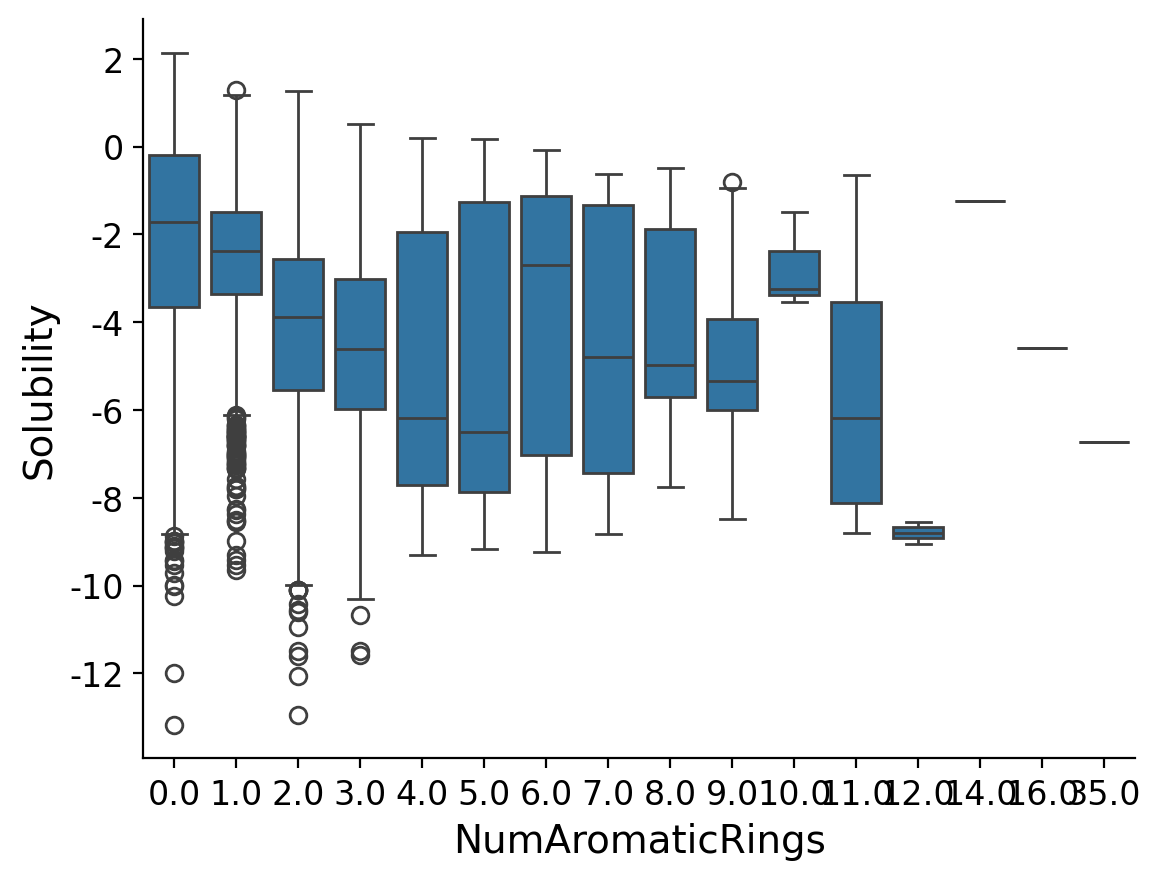

In [7]:
sns.boxplot(data=df, x="NumAromaticRings", y="Solubility")

What else do you think we can try?



## Similarity search

Now we can use fingerprints to search for the most similar structures in our database.
To do that, we will use the Morgan Fingerprint, which is similar to the ECFP discussed in the lecture.

In [8]:
fpgen = Chem.GetMorganGenerator(radius=2)

In [9]:
mols = [Chem.MolFromSmiles(smi) for smi in df["SMILES"].values[:2000]]
fps = fpgen.GetSparseFingerprints(mols)

[22:39:50] WARNING: not removing hydrogen atom without neighbors
[22:39:50] WARNING: not removing hydrogen atom without neighbors
[22:39:50] WARNING: not removing hydrogen atom without neighbors
[22:39:50] WARNING: not removing hydrogen atom without neighbors
[22:39:50] WARNING: not removing hydrogen atom without neighbors
[22:39:50] WARNING: not removing hydrogen atom without neighbors
[22:39:50] WARNING: not removing hydrogen atom without neighbors
[22:39:50] WARNING: not removing hydrogen atom without neighbors
[22:39:50] WARNING: not removing hydrogen atom without neighbors
[22:39:50] WARNING: not removing hydrogen atom without neighbors
[22:39:50] WARNING: not removing hydrogen atom without neighbors
[22:39:50] WARNING: not removing hydrogen atom without neighbors
[22:39:50] WARNING: not removing hydrogen atom without neighbors
[22:39:50] WARNING: not removing hydrogen atom without neighbors
[22:39:50] WARNING: not removing hydrogen atom without neighbors
[22:39:50] WARNING: not r

We will now use the Tanimoto similarity to compare the bit vectors. This similarity is defined as:

$$
T_s(X,Y) =  \frac{\displaystyle\sum_i ( X_i \land Y_i)}{\displaystyle\sum_i ( X_i \lor Y_i)}
$$

Where $\land$ is the bitwise AND operation, and $\lor$ is the bitwise OR.

In [10]:
COMPARE_AGAINST = 100

similarities = [
    DS.TanimotoSimilarity(fps[COMPARE_AGAINST], fp)
    for fp in fps
]

# finds the 4 most similar molecules, including itself
idx = np.argsort(similarities)[::-1][:4]

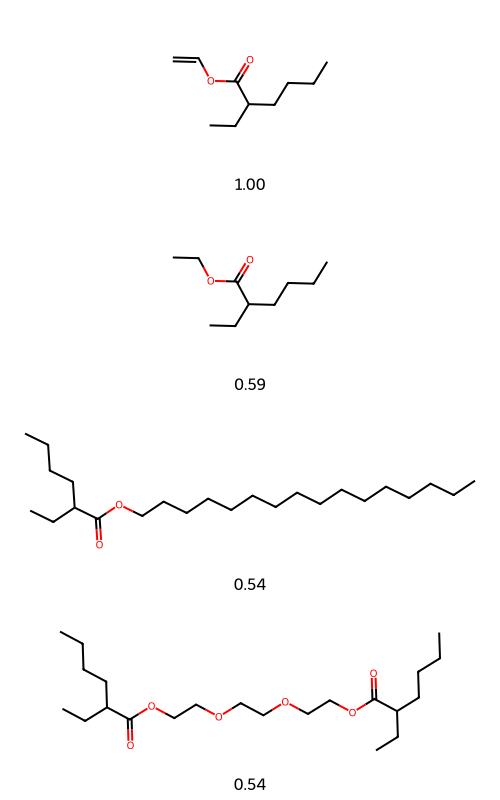

In [11]:
draw_molecules_row([mols[i] for i in idx], [similarities[i] for i in idx])

## Lab: what other insights?

Can you propose other hypotheses and insights to extract from this solubility dataset?
What about visualizations that could be interesting?

Produce new analysis that can be interesting for this dataset and justify it!

In [12]:
df.head()

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,...,10.0,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.0,1,G1,422.525,...,12.0,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934


I would expect a larger topological surface area to result in more solubility as the molecule has more polar regions to be dissolved by.

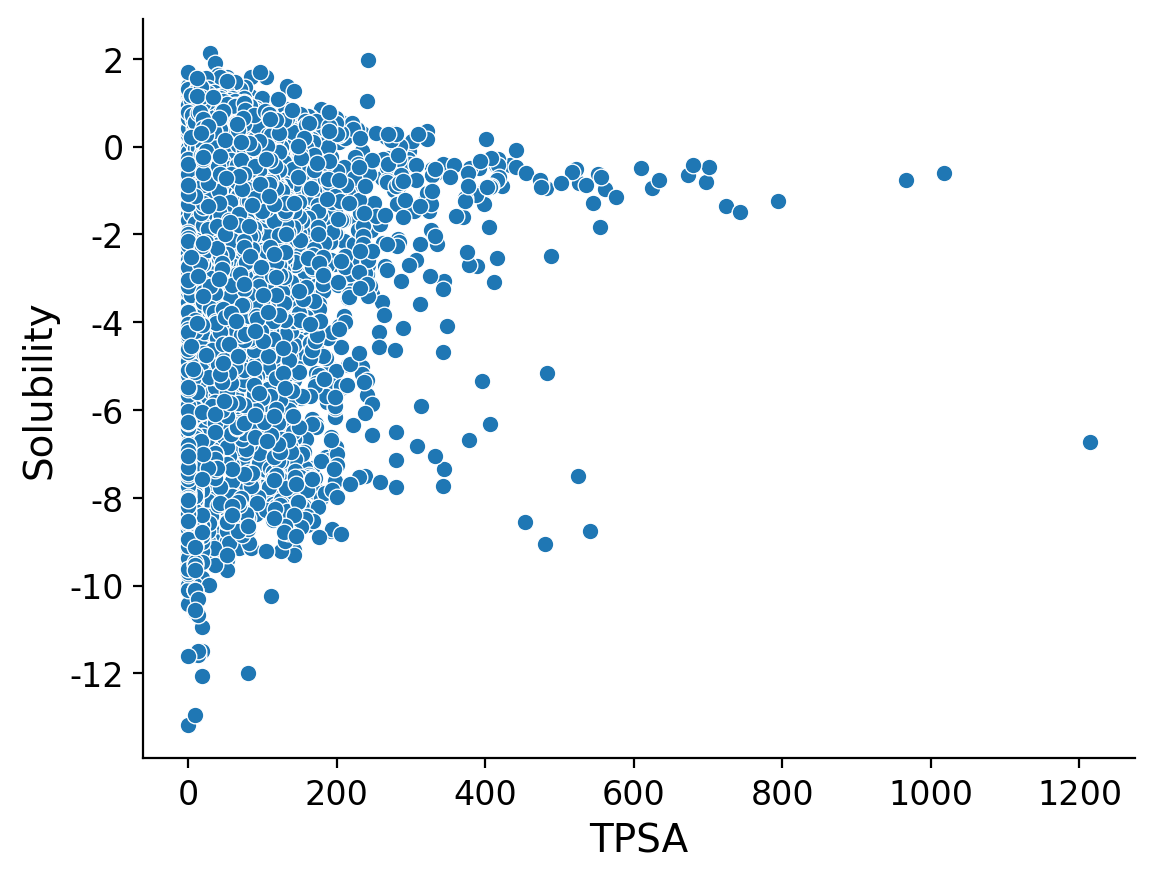

In [15]:
fig = sns.scatterplot(data = df, x = "TPSA", y  = "Solubility")
plt.show()

This appears to have a confounding variable, which might just be the overall size of the molecule. If a molecule has a high surface area and a high TPSA, then the TPSA may not matter. This can be done by dividing the TPSA by the LabuteASA.

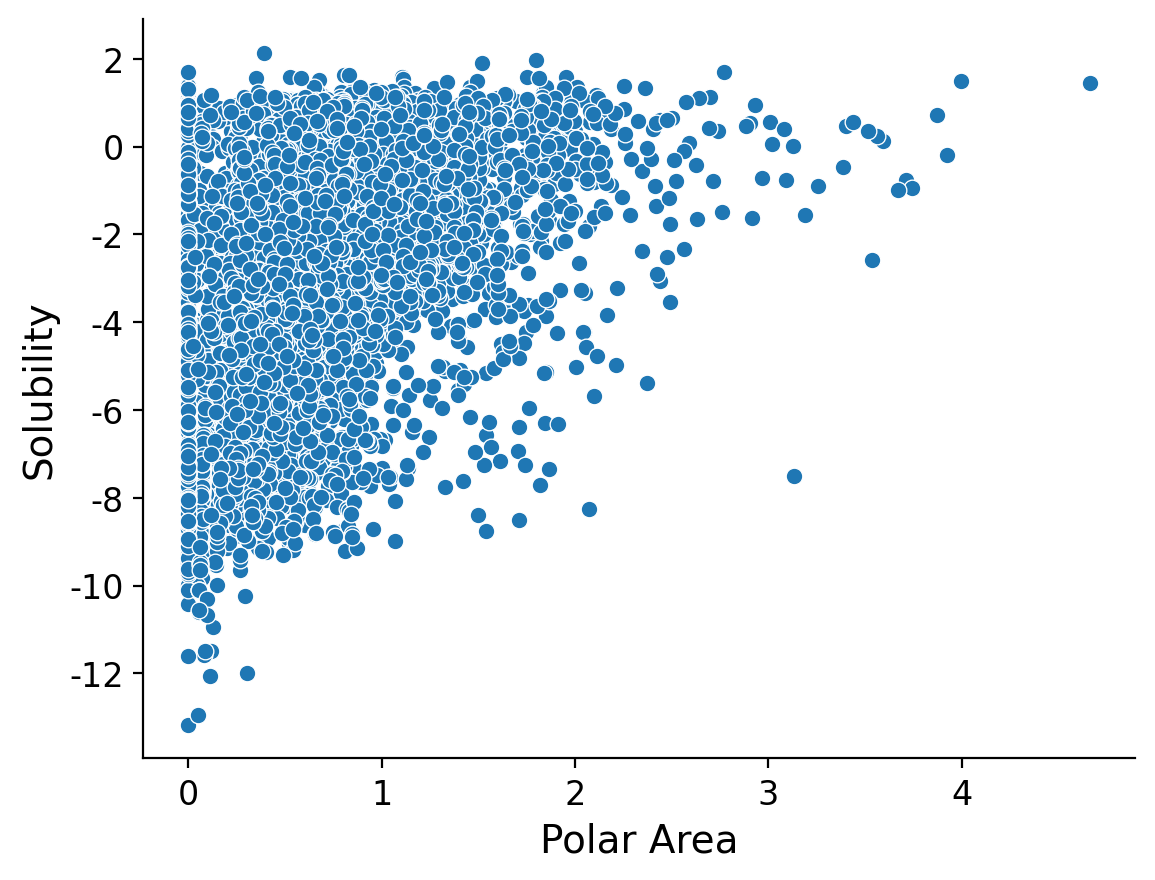

In [18]:
df["Polar Area"] = df["TPSA"]/df["LabuteASA"]
fig = sns.scatterplot(data = df, x = "Polar Area", y = "Solubility")
plt.show()

Although this metric appears to better predict the solubility, there still appears to be a confounding variable which greatly affects the solubility unrelated to the lower bound generated by the polar area of the molecule. I am going to explore other variables to see if anything else such as number of valency electrons can capture a relationship with solubility.

In [ ]:
target = "Solubility"
features = [col for col in df.columns if col != target]

# Create a vertical line of subplots (N rows, 1 column)
fig, axes = plt.subplots(nrows=len(features), ncols=1, figsize=(8, 5 * len(features)))

# Handle the case where there is only one feature (axes wouldn't be an array)
if len(features) == 1:
    axes = [axes]

for ax, col in zip(axes, features):
    # Check if column is numeric
    if pd.api.types.is_numeric_dtype(df[col]):
        sns.scatterplot(data=df, x=col, y=target, ax=ax)
    else:
        # Categorical data: Box and Whisker plot
        sns.boxplot(data=df, x=col, y=target, ax=ax)

    ax.set_title(f"{target} vs {col}")

plt.tight_layout()
plt.show()